# Laboratorijska vežba: Pretprocesiranje i osnovni zadaci eksploatacije podataka
Predmet: Otkrivanje znanja iz podataka

Ova vežba obuhvata pet ključnih faza:
1. Pretprocesiranje podataka (Čišćenje i transformacija)
2. Regresija
3. Klasifikacija
4. Grupisanje
5. Učenje podsticajem

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

print('Sve biblioteke su spremne.')

Sve biblioteke su spremne.


## 1. Pretprocesiranje podataka: Čišćenje i skaliranje
Pre nego što primenimo bilo koji algoritam mašinskog učenja, moramo osigurati kvalitet podataka. Fokusiraćemo se na:
- Imputaciju: Popunjavanje nedostajućih vrednosti.
- Skaliranje obeležja: Normalizacija opsega vrednosti.

In [2]:
# Kreiranje neurednog skupa podataka
data = {
    'Starost': [25, 30, np.nan, 40, 45, 20, 50, np.nan],
    'Plata': [50000, 60000, 55000, np.nan, 80000, 45000, 95000, 70000],
    'Iskustvo': [2, 5, 4, 10, 15, 1, 20, 8]
}
df = pd.DataFrame(data)
print('Originalni podaci sa nedostajućim vrednostima:')
print(df)

# 1.1. Rukovanje nedostajućim vrednostima (Imputacija srednjom vrednošću)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


Originalni podaci sa nedostajućim vrednostima:
   Starost    Plata  Iskustvo
0     25.0  50000.0         2
1     30.0  60000.0         5
2      NaN  55000.0         4
3     40.0      NaN        10
4     45.0  80000.0        15
5     20.0  45000.0         1
6     50.0  95000.0        20
7      NaN  70000.0         8
Podaci nakon imputacije i skaliranja:
   Starost  Plata  Iskustvo
0    -1.07  -0.97     -0.99
1    -0.53  -0.32     -0.50
2     0.00  -0.65     -0.67
3     0.53   0.00      0.30
4     1.07   0.97      1.11
5    -1.60  -1.30     -1.15
6     1.60   1.95      1.92
7     0.00   0.32     -0.02


In [3]:
# 1.1. Rukovanje nedostajućim vrednostima (Imputacija srednjom vrednošću)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print('Podaci nakon imputacije:')
print(df_imputed.round(2))

Podaci nakon imputacije:
   Starost    Plata  Iskustvo
0     25.0  50000.0       2.0
1     30.0  60000.0       5.0
2     35.0  55000.0       4.0
3     40.0  65000.0      10.0
4     45.0  80000.0      15.0
5     20.0  45000.0       1.0
6     50.0  95000.0      20.0
7     35.0  70000.0       8.0


In [4]:
# 1.2. Skaliranje obeležja (Standardizacija - Z-score)
# Formula: z = (x - u) / s
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df.columns)
print('Podaci nakon imputacije i skaliranja:')
print(df_scaled.round(2))

Podaci nakon imputacije i skaliranja:
   Starost  Plata  Iskustvo
0    -1.07  -0.97     -0.99
1    -0.53  -0.32     -0.50
2     0.00  -0.65     -0.67
3     0.53   0.00      0.30
4     1.07   0.97      1.11
5    -1.60  -1.30     -1.15
6     1.60   1.95      1.92
7     0.00   0.32     -0.02


### 📝 Zadatak za studente (Pretprocesiranje):
1.1 Promenite strategiju imputacije iz srednje vrednosti (mean) u medijanu (median). Kako se menjaju popunjene vrednosti?

1.2 Umesto StandardScaler, upotrebite MinMaxScaler. Koja je sada minimalna, a koja maksimalna vrednost u koloni 'Plata'?

## 2. Regresija: Predviđanje prinosa poljoprivredne kulture
Koristimo linearnu regresiju za procenu biomase neke poljoprivredne kulture (vredonsti biomase u ovom jednostavnom primeru su slučajno generisane).

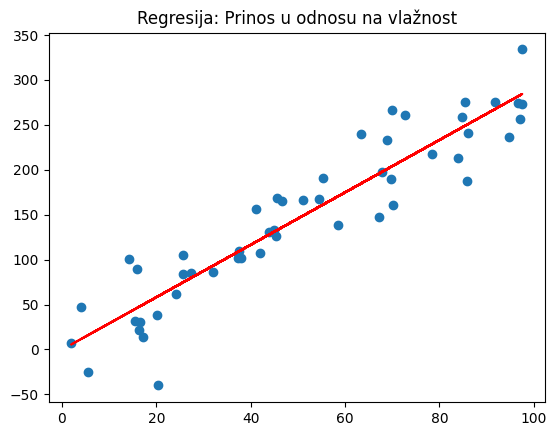

In [5]:
X_reg = np.random.rand(50, 1) * 100
y_reg = 3 * X_reg + np.random.randn(50, 1) * 30

reg_model = LinearRegression().fit(X_reg, y_reg)
plt.scatter(X_reg, y_reg)
plt.plot(X_reg, reg_model.predict(X_reg), color='red')
plt.title('Regresija: Prinos u odnosu na vlažnost')
plt.show()

### 📝 Zadatak za studente (regresija):
2.1 Izaberite neki drugi algoritam za regresiju iz scikit-learn biblioteke i napravite model njime. Da li je novi model bolji od linearne regresije? (Da biste ih uporedili, možda će vam trebati nešto iz sklearn.metrics.)

2.2 Učitajte California housing skup podataka iz sklearn.datasets i pokušajte da ga modelujete linearnom regresijom.

In [9]:
from sklearn.datasets import fetch_california_housing
#...

2.3 Pokušajte da ga modelujete vašom drugom odabranom regresionom metodom i uporedite koja je bolja.

## 3. Klasifikacija: Stablo odlučivanja

Simuliramo problem detekcije napada metodom Phishing-a na osnovu dužine URL-a koji je potencijalnoj žrtvi poslat i binarnog indikatora da li se koristi sigurna konekcija (HTTPS) ili ne (običan HTTP).

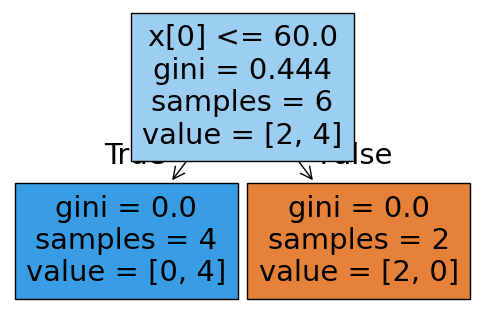

In [6]:
X_clf = [[20, 0], [25, 1], [80, 0], [40, 1], [150, 0], [30, 1]] # [URL_dužina, HTTPS]
y_clf = [1, 1, 0, 1, 0, 1] # 1=Siguran, 0=Phishing

clf_tree = DecisionTreeClassifier(max_depth=3).fit(X_clf, y_clf)
plt.figure(figsize=(6,4))
plot_tree(clf_tree, filled=True)
plt.show()

## Zadatak za studente (klasifikacija)
3.1 Šta je Gini?

3.2 Pokušajte da uradite klasifikaciju sa malo ozbiljnijim skupom podataka - covertype dataset, koji se nalazi u sklearn.datasets.

3.3 Kolika je tačnost vašeg modela?

3.4 Pokušajte da uradite klasifikaciju stohastičnom šumom (Random Forest).

3.5 Kolika je tačnost?

## 4. Grupisanje: K-Means

Napravićemo jednostavan skup podataka za grupisanje, koristeći funkciju make_blobs iz sklearn.datasets i grupisati ga korišćenjem medote K srednjih vrednosti.

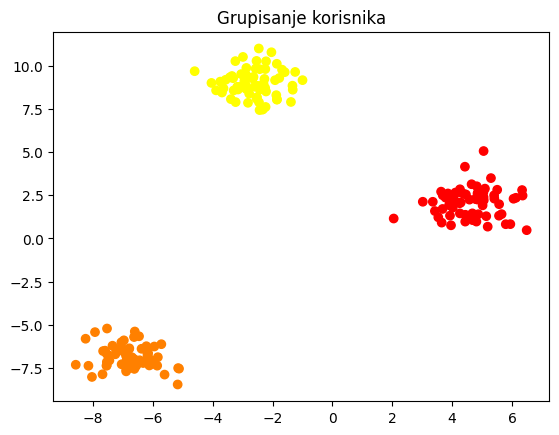

In [8]:
from sklearn.datasets import make_blobs
X_g, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

km = KMeans(n_clusters=3, n_init='auto').fit(X_g)
plt.scatter(X_g[:, 0], X_g[:, 1], c=km.labels_, cmap='autumn')
plt.title('Grupisanje korisnika')
plt.show()

## Zadaci za studente (grupisanje)
4.1 Pokušajte da nadjete kombinaciju parametara make_blobs za koju K means ne radi dobro.

4.2 Napravite skup tačaka za grupisanje koristeći metodu make_circles (sklearn.datasets.make_circles) i pokušajte da adekvatno grupišete taj skup podataka koristeći K srednjih vrednosti.

4.3 Pokušajte da nadjete i upotrebite neku drugu dostupnu metodu grupisanja koja daje bolji rezultat.